In [9]:
import sys
sys.path.append("..")

In [10]:
from src.data_utils import check_pairing

missing_labels, missing_images = check_pairing()
print("Missing labels:", len(missing_labels))
print("Missing images:", len(missing_images))

Missing labels: 0
Missing images: 0


In [11]:
from src.data_utils import validate_all_labels

validation_result = validate_all_labels()
validation_result

{'files_checked': 8099,
 'files_with_problems': 0,
 'empty_files': 0,
 'total_boxes': 75994,
 'class_counts': {0: 13802,
  1: 7730,
  2: 318,
  3: 8950,
  4: 134,
  5: 670,
  6: 759,
  7: 4647,
  8: 1945,
  9: 2790,
  10: 927,
  11: 15850,
  12: 11985,
  13: 157,
  14: 4560,
  15: 240,
  16: 530},
 'first_problems': []}

In [12]:
from PIL import Image
from src.config import IMAGES_DIR, IMAGE_EXTS, MAX_SIDE

longest = []
for f in IMAGES_DIR.iterdir():
    if f.suffix.lower() in IMAGE_EXTS:
        with Image.open(f) as im: 
            longest.append(max(im.size))

print("Images checked:", len(longest))
print("Largest longest-side:", max(longest))
print("Images above", MAX_SIDE, "px:", sum(s > MAX_SIDE for s in longest))

Images checked: 8099
Largest longest-side: 1024
Images above 1024 px: 0


Reloading: d:\Dl projects\object-detection\notebooks\..\src\visualise.py
12 images, 2 portrait


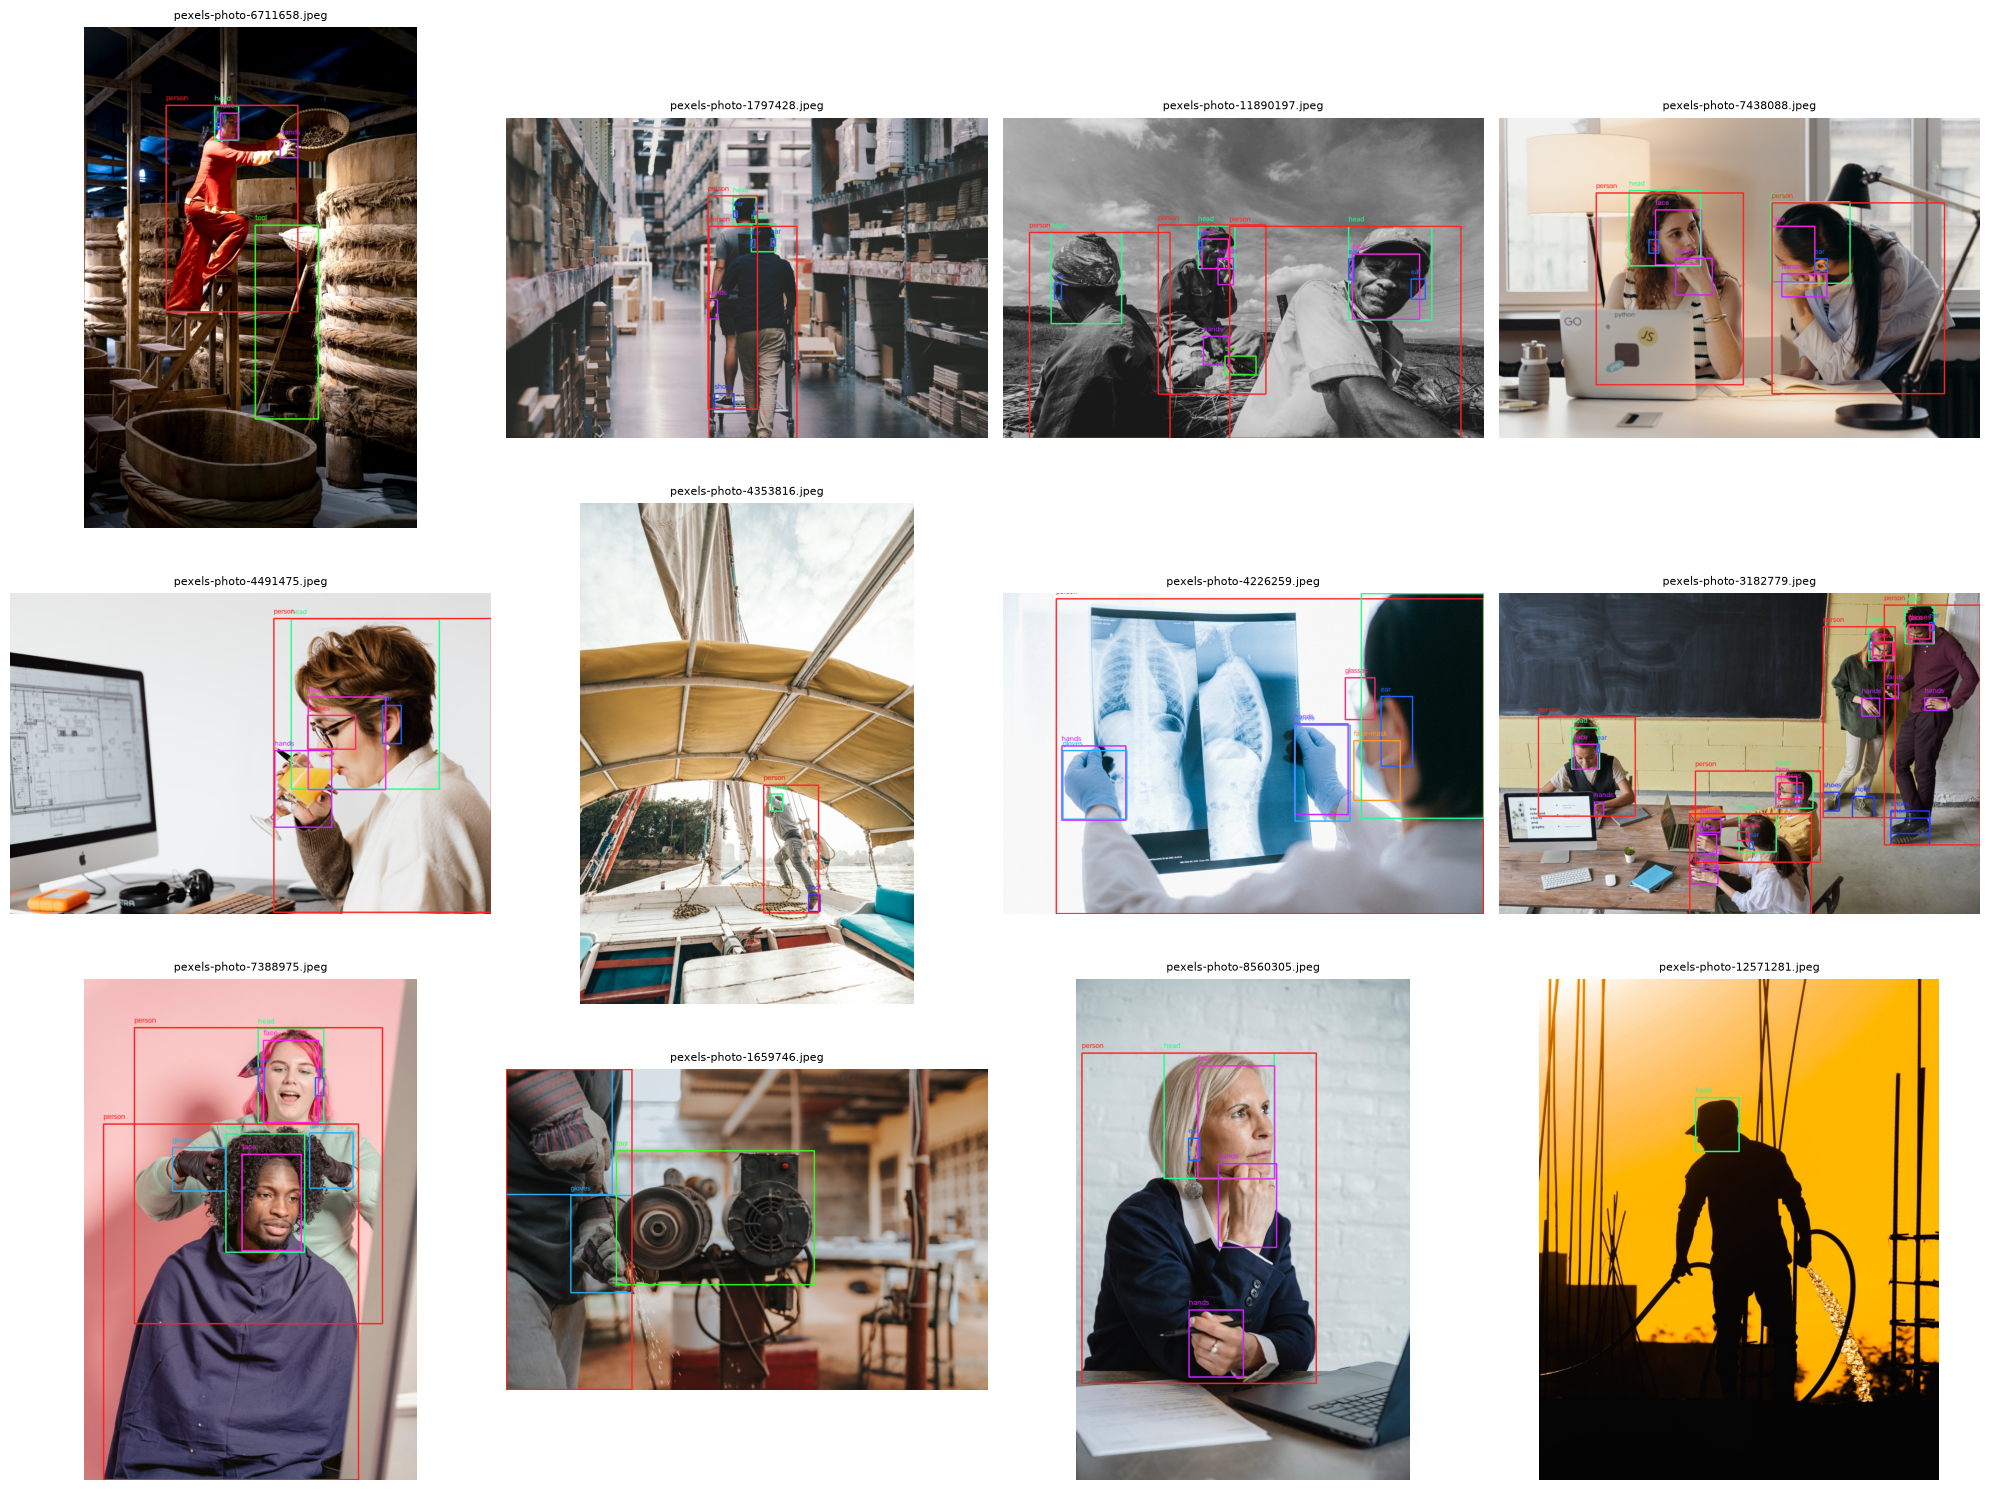

In [16]:
import random
import cv2
from src.config import IMAGES_DIR, IMAGE_EXTS, SEED
from src.visualise import show_grid
import importlib

visualise = importlib.import_module(show_grid.__module__)
print("Reloading:", visualise.__file__)

importlib.reload(visualise)
show_grid = visualise.show_grid

all_names = sorted(f.name for f in IMAGES_DIR.iterdir()
                   if f.suffix.lower() in IMAGE_EXTS)
rng = random.Random(SEED)

# 10 random images
random_names = rng.sample(all_names, 10)

# 2 portrait images (taller than wide), found from a random sample
portrait_names = []
for name in rng.sample(all_names, 300):
    if name in random_names:
        continue
    img = cv2.imread(str(IMAGES_DIR / name))
    if img is not None and img.shape[0] > img.shape[1]:
        portrait_names.append(name)
    if len(portrait_names) == 2:
        break

names = random_names + portrait_names
print(f"{len(names)} images, {len(portrait_names)} portrait")
show_grid(names, rows=3, cols=4)